# Final Project
**Name: Shani Bocas**

**Student ID: 200208970**
### Planetary Orbits:
#### The Three Body Problem

I am going to analyse the three-body system using Tatooine as a basis.

Techniques I will use:
- equations of motion
- kepler orbit equations
- solve_ivp
- cartesian co-ordinates
- two-body equations
- sci.integrate
- Axes3D

Sources:
- https://iopscience.iop.org/article/10.1088/0004-637X/780/1/14/pdf
- https://arxiv.org/pdf/1812.02754.pdf
- https://starwars.fandom.com/wiki/Tatooine
- https://openstax.org/books/university-physics-volume-1/pages/13-5-keplers-laws-of-planetary-motion#:~:text=In%20Satellite%20Orbits%20and%20Energy%2C%20we%20derived%20Kepler%E2%80%99s,the%20sum%20of%20the%20perihelion%20and%20the%20aphelion.
- https://towardsdatascience.com/modelling-the-three-body-problem-in-classical-mechanics-using-python-9dc270ad7767
- https://www.theforce.net/swtc/orbs.html#tatooine

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import animation
from scipy.integrate import solve_ivp
import scipy as sci

#### 1. Orbits of the stars 
To plot the orbits of the stars I first needed reference data. Usually I would use the time period and velocity as they appear from Earth.
However, Tatoo I and Tatoo II do not exist in our universe, therefore I used the orbital period and velocity from Tatooine.

In [117]:
au = 149597871e3
r = 1.08*au
M = 2*1.989e30
G = 6.67430e-11
T = 304*25

#Reference quantities from planet
v = 1.08*au*2*np.pi/(0.8*365*24*60**2)
t = 63*60**2

K1 = G*t*M/(r**2*v)
K2 = v*t/r

The websites state that the masses of the two stars add up to 2 Solar Masses. One star is a G1 spectral type, the other is a G2 spectral type. Due to this difference, and their similar size, I decided to give them similar mass values. As such, Tatoo I is given a mass of 1.1 Solar Masses and Tatoo II is given a mass of 0.9 Solar Masses.

In [119]:
#parameters of the stars
m1 = 1.1
m2 = 0.9

r1 = np.array([-0.047, 0, 0])
r2 = np.array([1.0, 0, 0])

r_c = (m1*r1+m2*r2)/(m1+m2) # COM

v1 = np.array([0.01, 0.01, 0])
v2 = np.array([-0.05, 0, -0.01])

v_c = (m1*v1+m2*v2)/(m1+m2) # COM

I used defined a function to calculate the positions of the orbit. By finding the distance between the stars in their 'starting positions' I could use the reference constants I calculated before to find their positions relative to each other throughout their orbit.

In [121]:
def TwoBody(w, t, G, m1, m2):
    r1 = w[:3]
    r2 = w[3:6]
    v1 = w[6:9]
    v2 = w[9:12]
    
    r = sci.linalg.norm(r2-r1) # magnitude of vector
    
    dv1_dt = K1*m2*(r2-r1)/(r**3)
    dv2_dt = K1*m1*(r1-r2)/(r**3)
    
    dr1_dt = K2*v1
    dr2_dt = K2*v2
    
    r_derivs = np.concatenate((dr1_dt, dr2_dt))
    
    derivs = np.concatenate((r_derivs, dv1_dt, dv2_dt))
    
    return derivs

The variables are combined into one array for ease of use and flattened to insure that they are only 1D arrays. This allows the functions to work with them.

The variable sol_2 is an array containing the positions of the stars relative to each other.

In [123]:
i = np.array([r1, r2, v1, v2])
i = i.flatten() # makes 1D
time = np.linspace(0, 100, 10000)# number of orbital periods to calculate for

sol_2 = sci.integrate.odeint(TwoBody, i, time, args=(G, m1, m2))

These are separated in to separate arrays for each star, containing the x, y and z co-ordinates.

In [125]:
sol_r1 = sol_2[:,:3]
sol_r2 = sol_2[:,3:6]

The orbit of the stars w.r.t each other can be converted to the orbits w.r.t the centre of mass.

For this I used the equation for the vector of the COM at each position and subtracted it from their positions relative to each other.

In [127]:
# find position w.r.t the centre of mass
sol_rc = (m1*sol_r1 + m2*sol_r2)/(m1 + m2)
sol_r1c = sol_r1 - sol_rc
sol_r2c = sol_r2 - sol_rc

I then plotted the orbits on a 3D axis using the subplot feature and added a position indicator using a scatter graph

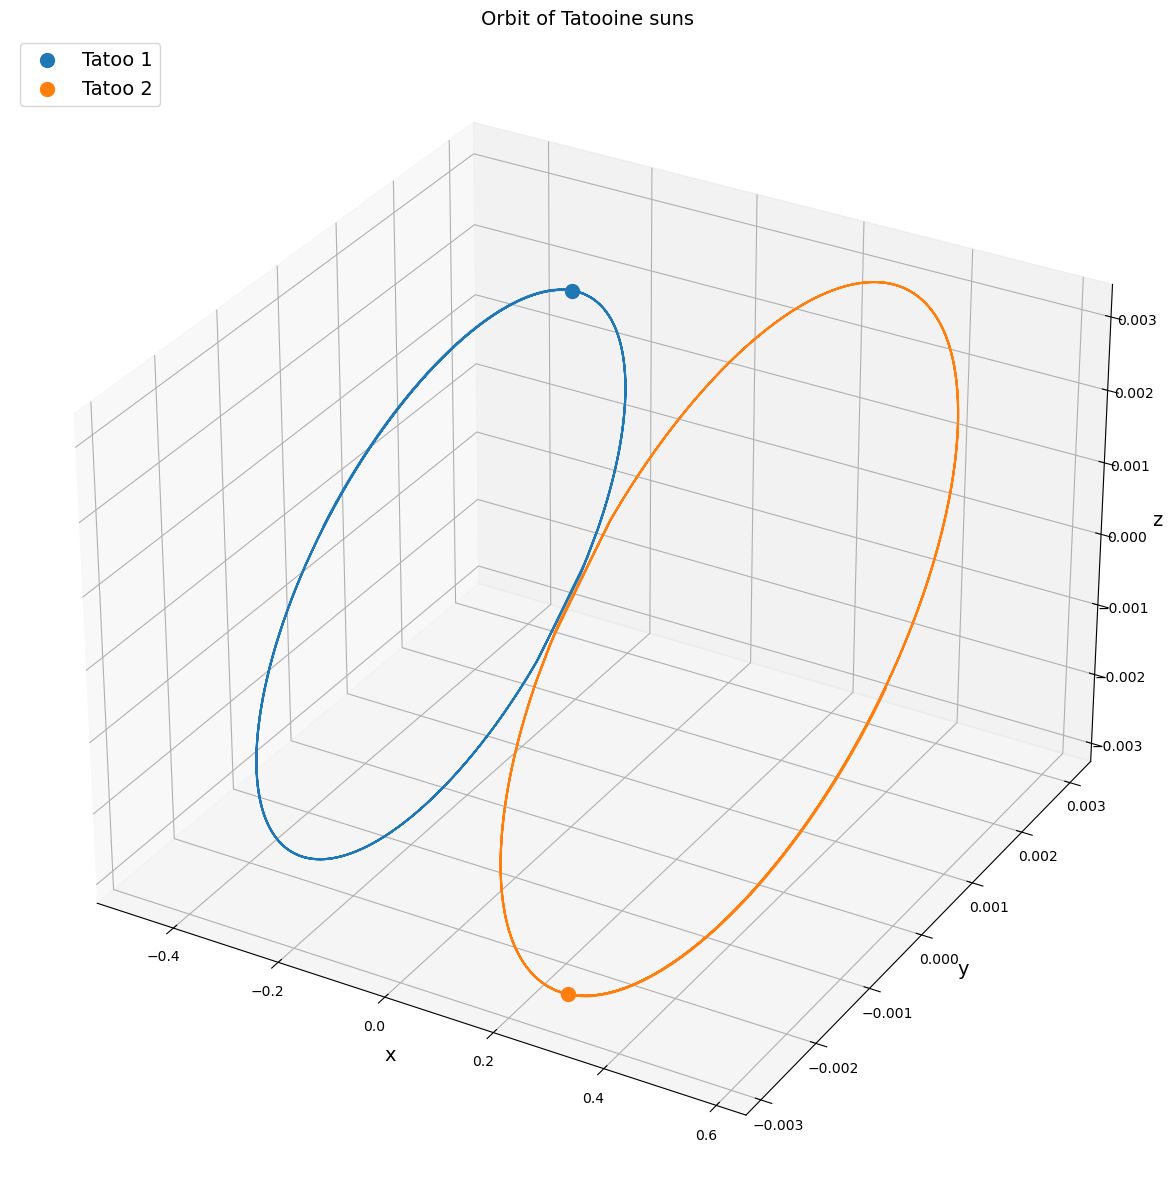

In [129]:
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')
ax.plot(sol_r1c[:,0], sol_r1c[:,1], sol_r1c[:,2])
ax.plot(sol_r2c[:,0], sol_r2c[:,1], sol_r2c[:,2])

ax.scatter(sol_r1c[-1, 0], sol_r1c[-1, 1], sol_r1c[-1, 2], marker = 'o', s=100, label='Tatoo 1')
ax.scatter(sol_r2c[-1, 0], sol_r2c[-1, 1], sol_r2c[-1, 2], marker = 'o', s=100, label='Tatoo 2')

ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
ax.set_zlabel('z', fontsize=14)
ax.set_title('Orbit of Tatooine suns', fontsize=14)
ax.legend(loc='upper left', fontsize=14)

#### 2. Orbit of the Planet

I tried multiple methods for plotting the orbit of the planet, however, the one that worked best was plotting a circle in the x and z axis. 

I constructed lists arrays containing the variables for the circle and used a linspace to iterate through the angles in the circle. I also included a zeros array to ensure I had an equal number of values for each set of co-ordinates.

##### 2.1 Attempt 1
I originally attempted to use the TwoBody function from before to find the orbit of the planet relative to the COM. This caused the orbit of the planet to appear as a right-angle originating from the COM of the stars.

In [132]:
# calculate orbit of planet around COM of the stars
au = 149597871e3
#rp = 1.08*au
r = 1.08

rp = np.array((r*np.cos(0), 0, r*np.sin(0)))

vp = np.array([0, 40, 0])
T = 0.8*365*24*60**2
#vp = 1.08*au*2*np.pi/(T)
#vp = np.array([0, 40, 0])
M = 2

mp = 4*np.pi**2*r**3/(G*T**2)
mp /= (M/2)

The method used here matches the method used for the stars exactly, with the exception of the variables.

mp is the mass of the planet and M is the total mass of the stars

In [134]:
i = np.array([rp, r_c, vp, v_c])
i = i.flatten() # makes 1D
time = np.linspace(0, 100, 1000)# number of orbital periods to calculate for

sol_p = sci.integrate.odeint(TwoBody, i, time, args=(G, mp, M))

In [135]:
sol_rp = sol_p[:,:3]
sol_rcom = sol_p[:,3:6]

In [136]:
sol_rcc = (mp*sol_rp + M*sol_rcom)/(mp + M)
sol_rpc = sol_rp - sol_rcc
sol_rcomc = sol_rcom - sol_rcc

The plot of this method does not resemble an orbit of any kind and, despite experimentation with this method, I was unable to produce any accurate plot.

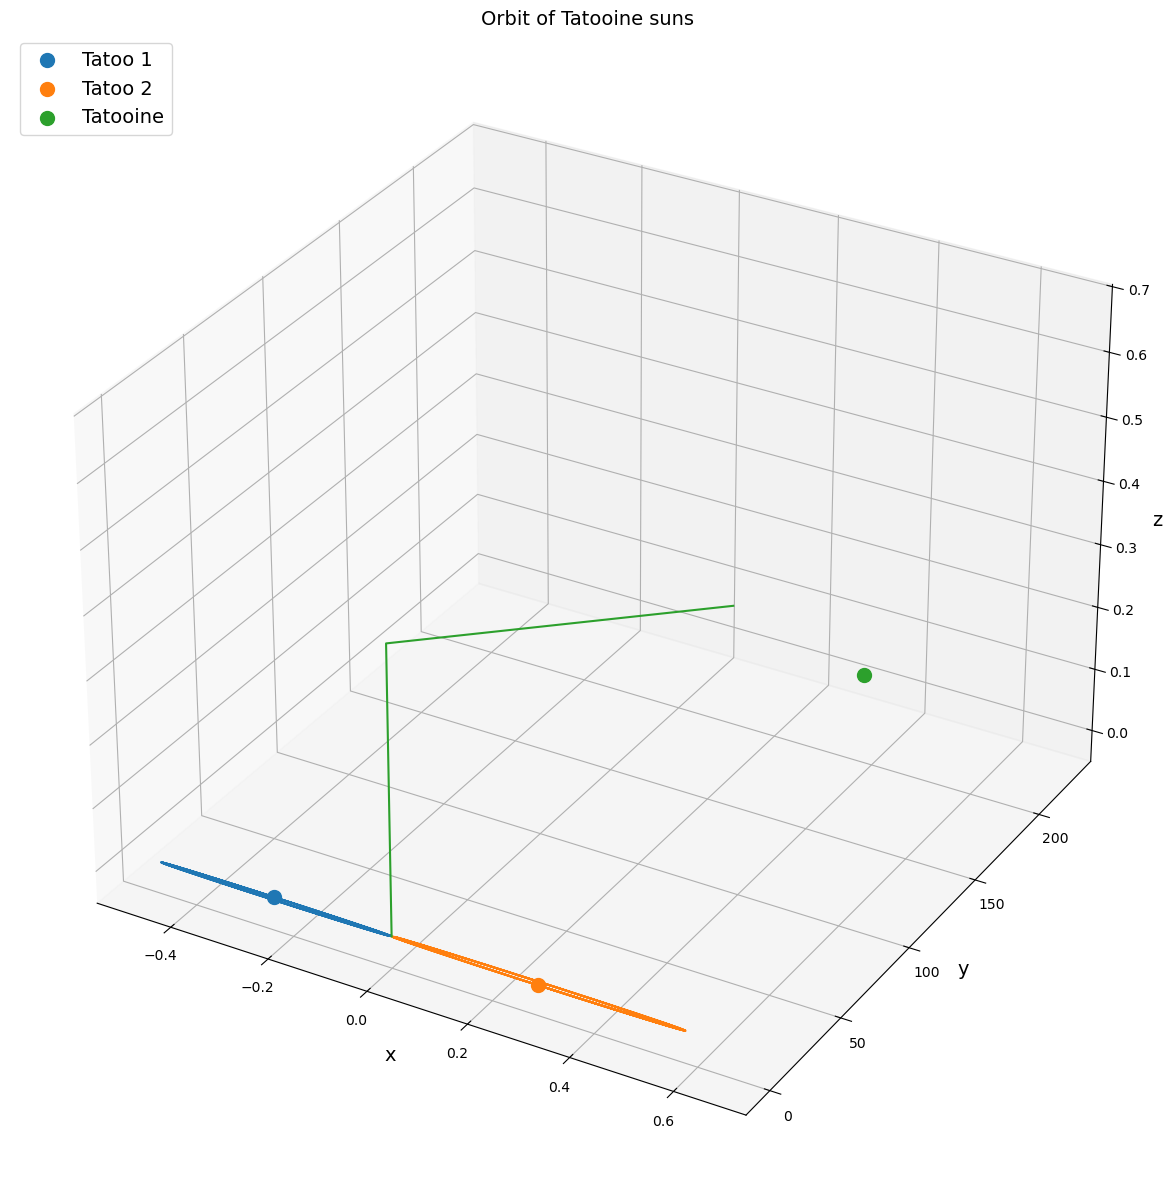

In [138]:
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')
ax.plot(sol_r1c[:,0], sol_r1c[:,1], sol_r1c[:,2])
ax.plot(sol_r2c[:,0], sol_r2c[:,1], sol_r2c[:,2])
ax.plot(sol_rpc[0], sol_rpc[1], sol_rpc[2]) #orbit of Tatooine

ax.scatter(sol_r1c[-1, 0], sol_r1c[-1, 1], sol_r1c[-1, 2], marker = 'o', s=100, label='Tatoo 1')
ax.scatter(sol_r2c[-1, 0], sol_r2c[-1, 1], sol_r2c[-1, 2], marker = 'o', s=100, label='Tatoo 2')
ax.scatter(sol_rpc[-1, 0], sol_rpc[-1, 1], sol_rpc[-1, 2], marker='o', s=100, label='Tatooine')

ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
ax.set_zlabel('z', fontsize=14)
ax.set_title('Orbit of Tatooine suns', fontsize=14)
ax.legend(loc='upper left', fontsize=14)

##### 2.2 Attempt 2

In this attempt I used the knowledge that planetary orbits are usually circular in shape around the COM and plotted the orbit using $\sin(z)$ and $\cos(z)$ where z is a linspace array containing 100 angles between 0 and 2$\pi$

The y vector was plotted as 0 using a zero array with 100 points to ensure that all the vectors had the same number of points

This method only works if you know the orbit of the planet is a circle around the centre of mass, and if you know the orbital radius.

In [140]:
# calculate orbit of planet around COM of the stars
au = 149597871e3
#rp = 1.08*au
r = 1.08
z = np.linspace(0, 2*np.pi, 100)
n = np.zeros(100)
rp = np.array((r*np.cos(z), n, r*np.sin(z)))

As before, the graph was plotted on a 3D axis. The same variables and code were used for plotting the orbits of the stars, with the planet plotted using the variables from the previous cell.

The scatter point was plotted at the position before last to match those of the stars.

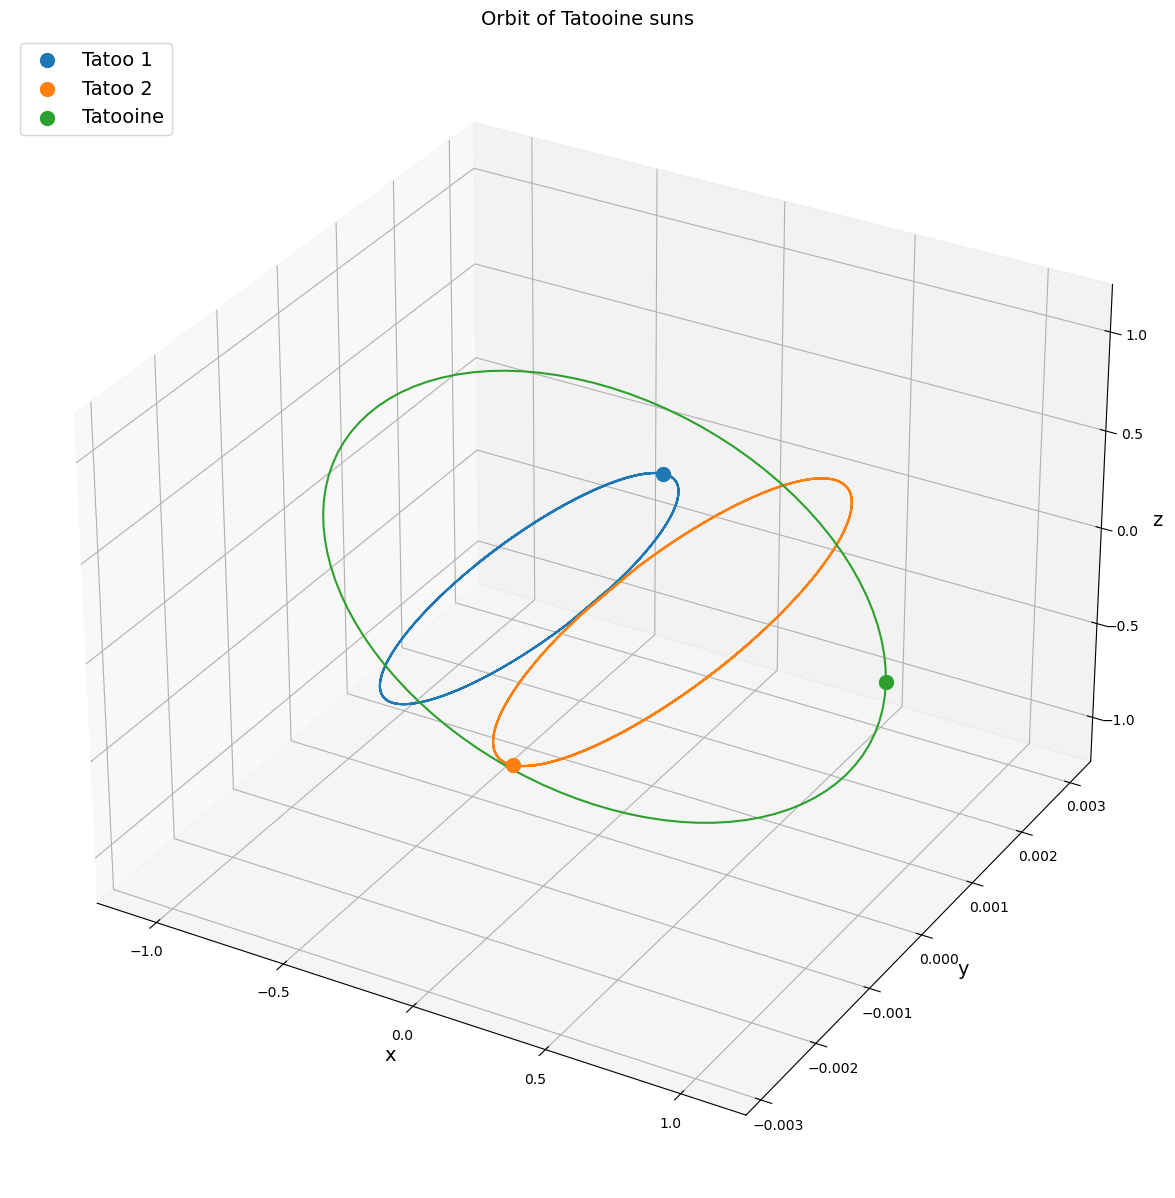

In [142]:
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')
ax.plot(sol_r1c[:,0], sol_r1c[:,1], sol_r1c[:,2])
ax.plot(sol_r2c[:,0], sol_r2c[:,1], sol_r2c[:,2])
ax.plot(rp[0], rp[1], rp[2]) #orbit of Tatooine

ax.scatter(sol_r1c[-1, 0], sol_r1c[-1, 1], sol_r1c[-1, 2], marker = 'o', s=100, label='Tatoo 1')
ax.scatter(sol_r2c[-1, 0], sol_r2c[-1, 1], sol_r2c[-1, 2], marker = 'o', s=100, label='Tatoo 2')
ax.scatter(1.08*np.cos(z[-1]), 0, 1.08*np.sin(z[-1]), marker='o', s=100, label='Tatooine')

ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
ax.set_zlabel('z', fontsize=14)
ax.set_title('Orbit of Tatooine suns', fontsize=14)
ax.legend(loc='upper left', fontsize=14)

#### 3. Three Stars

The plot of Three Stars orbiting each other is very different from the P-type orbit of a planet around two stars as shown above.

The code for the ThreeBody function was adapted from that of the TwoBody using the equations of motion:

$$
\frac{d^2r_1}{dt^2} = Gm_2\frac{r_2-r_1}{|r_2-r_1|^3} + Gm_3\frac{r_3-r_1}{|r_3-r_1|^3}
$$

In [144]:
def ThreeBody(w, t, G, m1, m2, m3):
    r1 = w[:3]
    r2 = w[3:6]
    r3 = w[6:9]
    
    v1 = w[9:12]
    v2 = w[12:15]
    v3 = w[15:18]
    
    r12 = sci.linalg.norm(r2-r1)
    r23 = sci.linalg.norm(r3-r2)
    r13 = sci.linalg.norm(r3-r1) # magnitude of vector
    
    dv1_dt = K1*m2*(r2-r1)/(r12**3) + K1*m3*(r3-r1)/(r13**3)
    dv2_dt = K1*m1*(r1-r2)/(r12**3) + K1*m3*(r3-r2)/(r23**3)
    dv3_dt = K1*m1*(r1-r3)/(r13**3) + K1*m2*(r2-r3)/(r23**3)
    
    dr1_dt = K2*v1
    dr2_dt = K2*v2
    dr3_dt = K2*v3
    
    r12_derivs = np.concatenate((dr1_dt, dr2_dt))
    r_derivs = np.concatenate((r12_derivs, dr3_dt))
    
    v12_derivs = np.concatenate((dv1_dt, dv2_dt))
    v_derivs = np.concatenate((v12_derivs, dv3_dt))
    
    derivs = np.concatenate((r_derivs, v_derivs))
    
    return derivs

These are arbitrary variables used for the express purpose of plotting the potential orbit.

In [146]:
# variables for a third star

m3 = 1.0

r3 = np.array((0, 1, 0))
v3 = np.array((0, -0.01, 0))

Due to the addition of a third star, the COM and the centre velocity must be recalculated. This is done using the same method as the COM for two stars.

In [148]:
r_c = (r1*m1+r2*m2+r3*m3)/(m1+m2+m3)

v_c = (m1*v1+m2*v2+m3*v3)/(m1+m2+m3)

Once again, the initial parameters are made up of the radii of the orbit of the three stars followed by their velocities.

This time the solution is calculated using the sci.integrate.odeint with the ThreeBody function and an additional argument of m3.

In [150]:
i = np.array([r1, r2, r3, v1, v2, v3])
i = i.flatten() # makes 1D
time = np.linspace(0, 100, 10000)# number of orbital periods to calculate for

sol_3 = sci.integrate.odeint(ThreeBody, i, time, args=(G, m1, m2, m3))

In [151]:
sol_r1 = sol_3[:,:3]
sol_r2 = sol_3[:,3:6]
sol_r3 = sol_3[:,6:9]

After separating the values for each star, these orbits are then calculated relative to the COM using the new COM and the same method as previous.

In [153]:
sol_rc = (m1*sol_r1 + m2*sol_r2 + m3*sol_r3)/(m1 + m2 + m3)
sol_r1c = sol_r1 - sol_rc
sol_r2c = sol_r2 - sol_rc
sol_r3c = sol_r3 - sol_rc

The graph for the orbit of three stars is very different from that of a planet orbiting binary stars and has a shorter period.

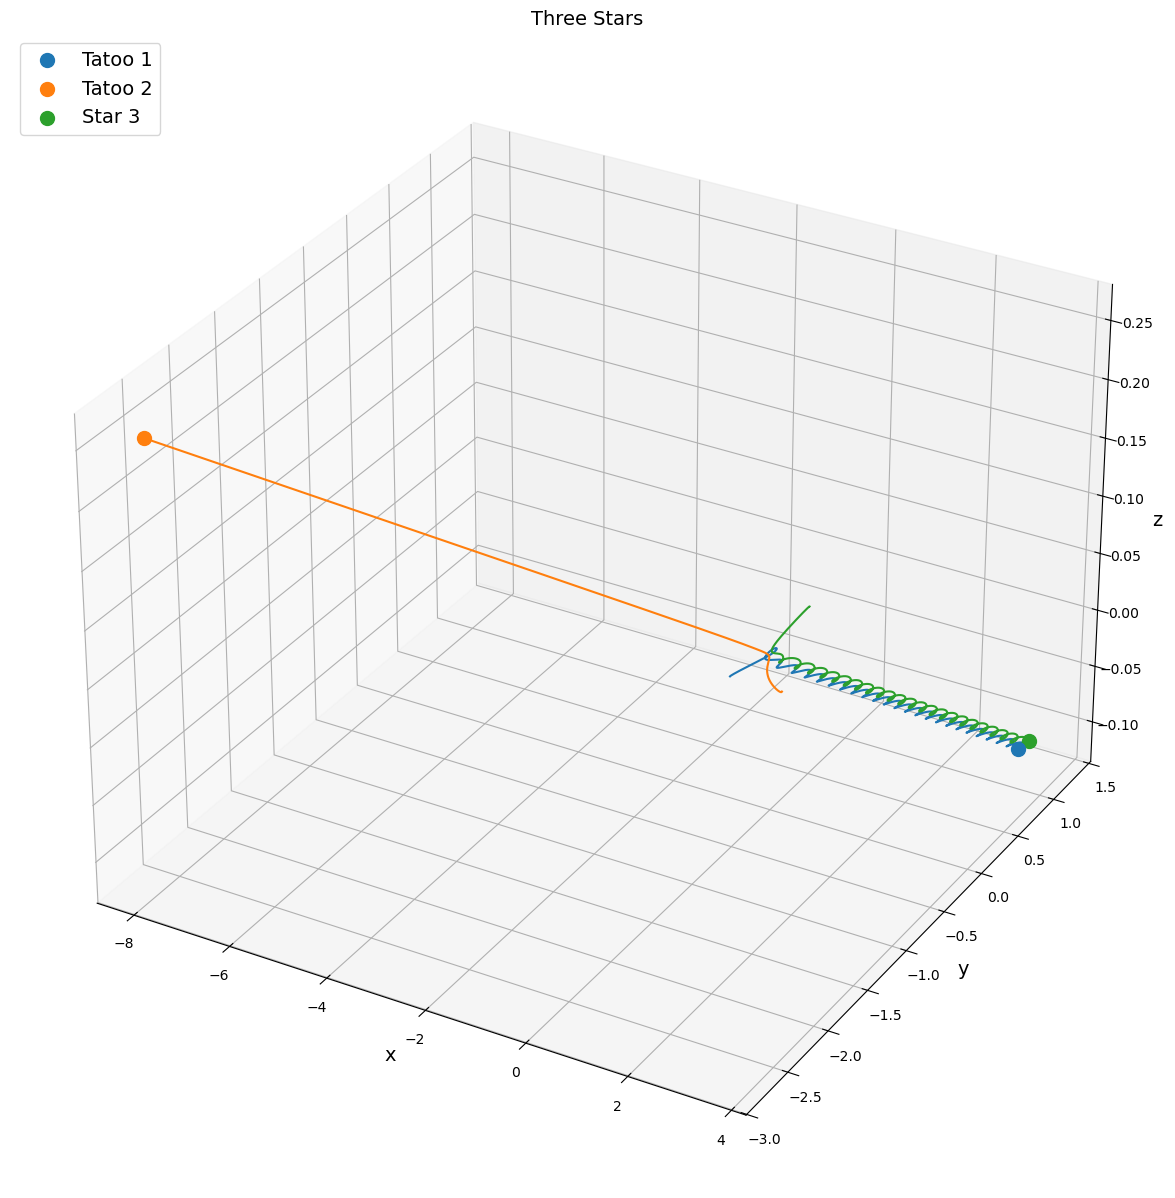

In [155]:
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')
ax.plot(sol_r1c[:,0], sol_r1c[:,1], sol_r1c[:,2])
ax.plot(sol_r2c[:,0], sol_r2c[:,1], sol_r2c[:,2])
ax.plot(sol_r3c[:,0], sol_r3c[:,1], sol_r3c[:,2])

ax.scatter(sol_r1c[-1, 0], sol_r1c[-1, 1], sol_r1c[-1, 2], marker = 'o', s=100, label='Tatoo 1')
ax.scatter(sol_r2c[-1, 0], sol_r2c[-1, 1], sol_r2c[-1, 2], marker = 'o', s=100, label='Tatoo 2')
ax.scatter(sol_r3c[-1, 0], sol_r3c[-1, 1], sol_r3c[-1, 2], marker = 'o', s=100, label='Star 3')

ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
ax.set_zlabel('z', fontsize=14)
ax.set_title('Three Stars', fontsize=14)
ax.legend(loc='upper left', fontsize=14)

#### 4. Comparison
There is a stark difference between the orbit of a three stars and the orbit of a planet around binary stars. This is because the mass of the planet is much less than that of the stars it is orbiting, which means it shows little to no gravitational interference with the stars' orbits. In comparison, the stars possess a great enough mass to show a large effect on each other.

The P-type orbit is also far more stable, with the stars and planet remaining on the same path as long as there is no outside interference. The orbit of the three stars breaks down after one rotation, with the two most massive stars continuing to orbit each other in a stable spiral while the smaller star travels in the opposite direction.

This is due to the number of large masses and gravitational forces acting on each other and pulling each other in different directions.

#### 4. Conclusion

In conclusion, the best way I have found to plot a P-type orbit around binary stars is to first plot the orbit of the stars relative to each other and then plot the orbit of the planet using a circle with the appropriate radius.
This is very different than plotting three stars orbiting each other which requires calculating an equation of motion for all three stars using the mass and radius of the bodies it is orbiting. 

The code for the ThreeBody and TwoBody functions can be easily adapted to work for more many bodies by adding extra variables and calculating the relevant COM and radii.

$$
\frac{d^2r_1}{dt^2} = Gm_2\frac{r_2-r_1}{|r_2-r_1|^3} + Gm_3\frac{r_3-r_1}{|r_3-r_1|^3} + Gm_4\frac{r_4-r_1}{|r_4-r_1|^3} + ... + Gm_n\frac{r_n-r_1}{|r_n-r_1|^3}
$$
for n bodies.

The orbit of the planet around its binary stars is not that different in appearance or apparent stability to that of the Earth around its sun. This contrasts greatly from the orbit of the three stars which is very unstable and does not happen for more than one rotation before rejecting the smallest mass and carrying on as a binary.